In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df=pd.read_csv("/content/supply_chain_delivery_risk_small_dataset.csv")

In [ ]:
df.head()

,Order_ID,Shipping_Mode,Customer_Segment,Product_Category,Order_Region,Shipping_Distance_km,Processing_Time_days,Shipping_Time_days,Scheduled_Delivery_Days,Order_Value,Previous_Delays,Warehouse_Load_pct,Late_Delivery_Risk
0,SC001,Standard Class,Consumer,Office Supplies,East,521,2,3,7,1879,4,41,1
1,SC002,Same Day,Consumer,Technology,South,467,2,1,5,3457,4,83,0
2,SC003,Same Day,Home Office,Furniture,South,346,4,6,11,2747,1,73,0
3,SC004,Standard Class,Corporate,Technology,East,724,5,5,10,12155,3,98,1
4,SC005,Same Day,Consumer,Office Supplies,East,1307,5,6,13,3350,0,35,0


In [ ]:
df.shape

(100, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Order_ID                 100 non-null    object
 1   Shipping_Mode            100 non-null    object
 2   Customer_Segment         100 non-null    object
 3   Product_Category         100 non-null    object
 4   Order_Region             100 non-null    object
 5   Shipping_Distance_km     100 non-null    int64 
 6   Processing_Time_days     100 non-null    int64 
 7   Shipping_Time_days       100 non-null    int64 
 8   Scheduled_Delivery_Days  100 non-null    int64 
 9   Order_Value              100 non-null    int64 
 10  Previous_Delays          100 non-null    int64 
 11  Warehouse_Load_pct       100 non-null    int64 
 12  Late_Delivery_Risk       100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [ ]:
df.columns

Index(['Order_ID', 'Shipping_Mode', 'Customer_Segment', 'Product_Category',
       'Order_Region', 'Shipping_Distance_km', 'Processing_Time_days',
       'Shipping_Time_days', 'Scheduled_Delivery_Days', 'Order_Value',
       'Previous_Delays', 'Warehouse_Load_pct', 'Late_Delivery_Risk'],
      dtype='object')

In [ ]:
df.describe()

,Shipping_Distance_km,Processing_Time_days,Shipping_Time_days,Scheduled_Delivery_Days,Order_Value,Previous_Delays,Warehouse_Load_pct,Late_Delivery_Risk
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000
mean,784.130000,2.940000,4.730000,8.780000,7860.550000,2.110000,65.150000,0.43000
std,409.119741,1.354529,2.321855,2.932162,4767.370707,1.377269,19.953165,0.49757
min,36.000000,1.000000,1.000000,3.000000,258.000000,0.000000,30.000000,0.00000
25%,478.250000,2.000000,3.000000,7.000000,3343.000000,1.000000,50.000000,0.00000
50%,742.500000,3.000000,5.000000,8.500000,7682.000000,2.000000,63.000000,0.00000
75%,1131.500000,4.000000,7.000000,11.000000,12218.250000,3.000000,82.250000,1.00000
max,1491.000000,5.000000,8.000000,15.000000,14946.000000,4.000000,100.000000,1.00000


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Shipping_Mode,0
Customer_Segment,0
Product_Category,0
Order_Region,0
Shipping_Distance_km,0
Processing_Time_days,0
Shipping_Time_days,0
Scheduled_Delivery_Days,0
Order_Value,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Late_Delivery_Risk"].value_counts()

,count
Late_Delivery_Risk,
0,57
1,43


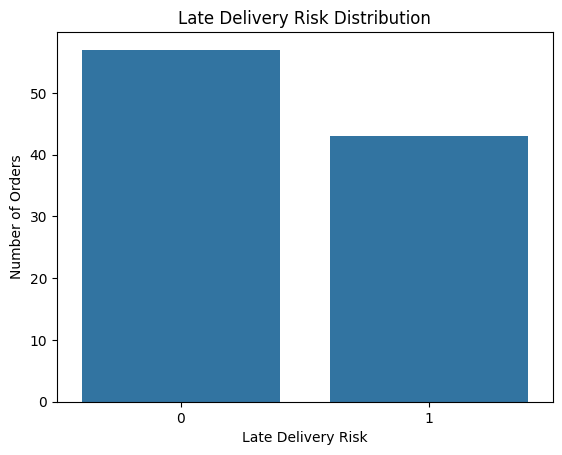

In [ ]:
sns.countplot(x="Late_Delivery_Risk", data=df)

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Orders")
plt.show()

In [ ]:
X = df.drop("Late_Delivery_Risk", axis=1)
y = df["Late_Delivery_Risk"]

In [ ]:
categorical_features = [
    "Shipping_Mode",
    "Customer_Segment",
    "Product_Category",
    "Order_Region"
]

numerical_features = [
    "Shipping_Distance_km",
    "Processing_Time_days",
    "Shipping_Time_days",
    "Scheduled_Delivery_Days",
    "Order_Value",
    "Previous_Delays",
    "Warehouse_Load_pct"
]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80, 12)
Testing data: (20, 12)


In [ ]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [ ]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Shipping_Distance_km',
                                                   'Processing_Time_days',
                                                   'Shipping_Time_days',
                                                   'Scheduled_Delivery_Days',
                                                   'Order_Value',
                                                   'Previous_Delays',
                                                   'Warehouse_Load_pct']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Shipping_Mode',
                                                   'Customer_Segment',
                                                   'Product_Category',
                                                   'Order_Region'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred_lr = logistic_model.predict(X_test)

In [ ]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.8


In [ ]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

In [ ]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Shipping_Distance_km',
                                                   'Processing_Time_days',
                                                   'Shipping_Time_days',
                                                   'Scheduled_Delivery_Days',
                                                   'Order_Value',
                                                   'Previous_Delays',
                                                   'Warehouse_Load_pct']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Shipping_Mode',
                                                   'Customer_Segment',
                                                   'Product_Category',
                                                   'Order_Region'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred_rf = random_forest_model.predict(X_test)

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.85


In [ ]:
gradient_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

In [ ]:
gradient_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Shipping_Distance_km',
                                                   'Processing_Time_days',
                                                   'Shipping_Time_days',
                                                   'Scheduled_Delivery_Days',
                                                   'Order_Value',
                                                   'Previous_Delays',
                                                   'Warehouse_Load_pct']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Shipping_Mode',
                                                   'Customer_Segment',
                                                   'Product_Category',
                                                   'Order_Region'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [ ]:
y_pred_gb = gradient_model.predict(X_test)

In [ ]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)

Gradient Boosting Accuracy: 0.75


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_gb
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.80
1,Random Forest,0.85
2,Gradient Boosting,0.75


In [ ]:
results["Accuracy"] = results["Accuracy"] * 100

results

,Model,Accuracy
0,Logistic Regression,80.0
1,Random Forest,85.0
2,Gradient Boosting,75.0


In [ ]:
def evaluate_model(y_test, y_pred, model_name):
    print("\n", model_name)
    print("-" * 40)
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

In [ ]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_gb, "Gradient Boosting")


 Logistic Regression
----------------------------------------
Accuracy : 0.8
Precision: 1.0
Recall   : 0.5555555555555556
F1 Score : 0.7142857142857143

 Random Forest
----------------------------------------
Accuracy : 0.85
Precision: 1.0
Recall   : 0.6666666666666666
F1 Score : 0.8

 Gradient Boosting
----------------------------------------
Accuracy : 0.75
Precision: 0.75
Recall   : 0.6666666666666666
F1 Score : 0.7058823529411765


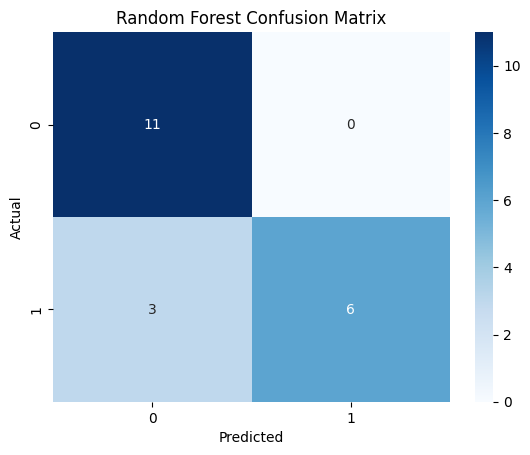

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
new_order = pd.DataFrame({
    "Shipping_Mode": ["Standard Class"],
    "Customer_Segment": ["Corporate"],
    "Product_Category": ["Technology"],
    "Order_Region": ["West"],
    "Shipping_Distance_km": [1200],
    "Processing_Time_days": [5],
    "Shipping_Time_days": [7],
    "Scheduled_Delivery_Days": [10],
    "Order_Value": [8000],
    "Previous_Delays": [3],
    "Warehouse_Load_pct": [90]
})

In [ ]:
prediction = random_forest_model.predict(new_order)

print("Predicted Late Delivery Risk:", prediction[0])

Predicted Late Delivery Risk: 1
